In [1]:
!kaggle datasets download -d blourdhuraju/dogs-vs-cats-classification

Dataset URL: https://www.kaggle.com/datasets/blourdhuraju/dogs-vs-cats-classification
License(s): CC0-1.0
100% 775M/775M [00:04<00:00, 165MB/s]



In [2]:
!unzip dogs-vs-cats-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07458.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07459.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07460.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07461.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07462.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07463.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07464.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07465.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07466.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07467.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07468.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train_07469.jpg  
  inflating: dogs-vs-cats-classification/train/dogs/dog_train

In [3]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [4]:
conv_base = VGG16(
    weights='imagenet',
    include_top = False,
    input_shape=(150,150,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [6]:
conv_base.trainable = False

In [7]:
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    array_to_img,
    img_to_array,
    load_img
)

In [9]:
batch_size = 32

train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        '/content/dogs-vs-cats-classification/train',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        '/content/dogs-vs-cats-classification/test',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

Found 19943 images belonging to 2 classes.
Found 2495 images belonging to 2 classes.


In [10]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(
        train_generator,
        epochs=10,
        validation_data=validation_generator)

Epoch 1/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8208 - loss: 0.4226

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


624/624 ━━━━━━━━━━━━━━━━━━━━ 192s 291ms/step - accuracy: 0.8670 - loss: 0.3047 - val_accuracy: 0.9002 - val_loss: 0.2230
Epoch 2/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.8987 - loss: 0.2359 - val_accuracy: 0.9130 - val_loss: 0.2048
Epoch 3/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 166s 265ms/step - accuracy: 0.9035 - loss: 0.2222 - val_accuracy: 0.9170 - val_loss: 0.1995
Epoch 4/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 164s 263ms/step - accuracy: 0.9100 - loss: 0.2104 - val_accuracy: 0.9174 - val_loss: 0.1970
Epoch 5/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.9134 - loss: 0.2046 - val_accuracy: 0.9190 - val_loss: 0.1939
Epoch 6/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 166s 266ms/step - accuracy: 0.9159 - loss: 0.1935 - val_accuracy: 0.9186 - val_loss: 0.1898
Epoch 7/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 165s 265ms/step - accuracy: 0.9217 - loss: 0.1883 - val_accuracy: 0.9082 - val_loss: 0.2108
Epoch 8/10
624/624 ━━━━━━━━━━━━━━━━━━━━ 169s 271ms/step - accuracy: 0.9235 - loss: 0.18

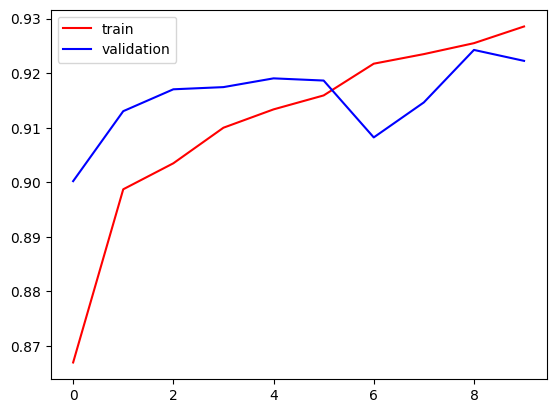

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

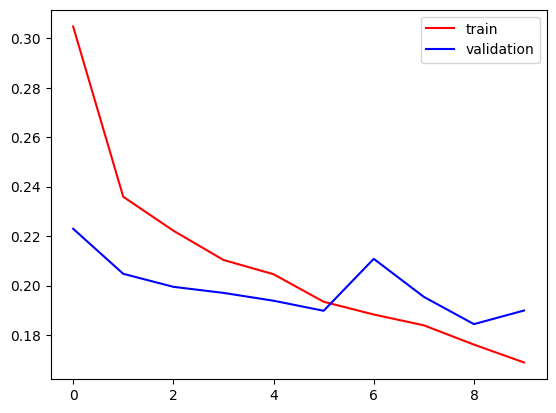

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()